In [1]:
pip install networkx python-louvain geopandas matplotlib pulp

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install python-igraph

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install cairocffi  # Opcional, para visualización

Note: you may need to restart the kernel to use updated packages.


In [4]:
import osmnx as ox
import networkx as nx
import community as community_louvain
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, value
import random
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [5]:
# --- 1. Construcción del grafo ---
place_name = "Alto Selva Alegre, Arequipa, Perú"
G = ox.graph_from_place(place_name, network_type="walk")

# Convertir el grafo dirigido a no dirigido
G = G.to_undirected()

# Añadimos nodos con probabilidades de rabia
for node_id in G.nodes:
    G.nodes[node_id]['prob_rabies'] = random.uniform(0, 1)  # Probabilidad aleatoria entre 0 y 1 babilidad aleatoria entre 0 y 1
    
print(G.nodes(data=True))

[(531321521, {'y': -16.384358, 'x': -71.5196891, 'street_count': 3, 'prob_rabies': 0.41830271222441207}), (531321526, {'y': -16.3840867, 'x': -71.519317, 'street_count': 4, 'prob_rabies': 0.8876542639709027}), (531321541, {'y': -16.3829736, 'x': -71.5177944, 'street_count': 4, 'prob_rabies': 0.6570322508033964}), (531321549, {'y': -16.3817615, 'x': -71.5161259, 'street_count': 4, 'prob_rabies': 0.6050779896048177}), (531322095, {'y': -16.3889778, 'x': -71.5261027, 'street_count': 4, 'prob_rabies': 0.9985564158499654}), (531322186, {'y': -16.3866548, 'x': -71.5211902, 'street_count': 3, 'prob_rabies': 0.6858015935479996}), (531322221, {'y': -16.3899674, 'x': -71.5273342, 'street_count': 3, 'prob_rabies': 0.37575908492657695}), (531322369, {'y': -16.3885011, 'x': -71.5264568, 'street_count': 3, 'prob_rabies': 0.05892333784633741}), (531322380, {'y': -16.3880935, 'x': -71.526548, 'street_count': 4, 'prob_rabies': 0.18658016619974238}), (551424457, {'y': -16.3895902, 'x': -71.5268283, 'str

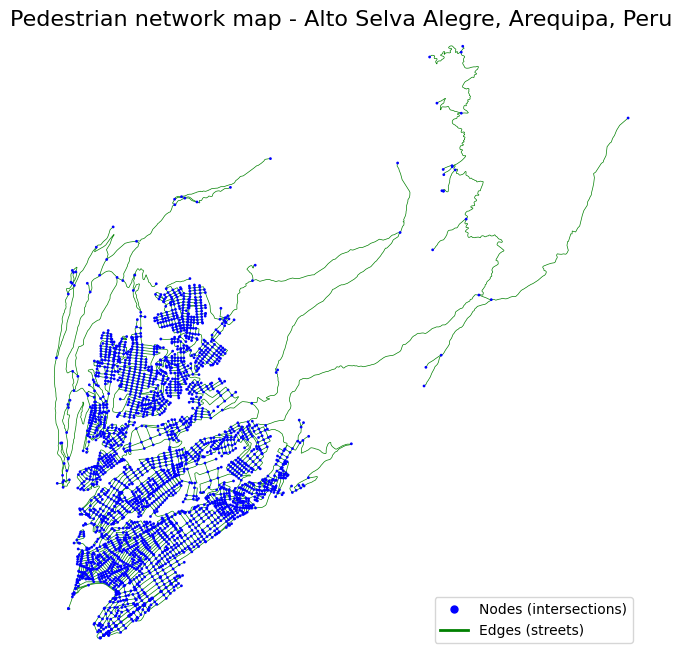

In [6]:
# Graficar el grafo y obtener los ejes
fig, ax = ox.plot_graph(
    G,
    node_size=4,
    node_color="blue",
    edge_color="green",         # Color de las aristas
    edge_linewidth=0.5,        # Ancho de las aristas
    bgcolor="white",
    show=False,  # No mostrar inmediatamente
    close=False  # No cerrar automáticamente
)

# Agregar un título al gráfico
ax.set_title("Pedestrian network map - Alto Selva Alegre, Arequipa, Peru", fontsize=16)

# Crear elementos para la leyenda
legend_elements = [
    Line2D([0], [0], color="blue", marker='o', markersize=5, linestyle="None", label="Nodes (intersections)"),
    Line2D([0], [0], color="green", linewidth=2, label="Edges (streets)")
]

# Agregar la leyenda al gráfico
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, frameon=True, facecolor="white")

# Mostrar el gráfico
plt.show()

In [7]:
print(G.edges(data=True))

[(531321521, 4073426337, {'osmid': 639169490, 'oneway': False, 'lanes': '2', 'name': 'Avenida Arequipa', 'highway': 'secondary', 'maxspeed': '50', 'reversed': True, 'length': 8.167}), (531321521, 4073426339, {'osmid': 639169490, 'oneway': False, 'lanes': '2', 'name': 'Avenida Arequipa', 'highway': 'secondary', 'maxspeed': '50', 'reversed': False, 'length': 10.127}), (531321521, 2112344605, {'osmid': 1286418778, 'name': 'Avenida Pacífico', 'highway': 'residential', 'maxspeed': '40', 'oneway': False, 'reversed': False, 'length': 6.971}), (531321526, 1264333146, {'osmid': 110836061, 'name': 'Avenida Pacífico', 'highway': 'residential', 'oneway': False, 'reversed': True, 'length': 75.239}), (531321526, 10998052151, {'osmid': 110836061, 'name': 'Avenida Pacífico', 'highway': 'residential', 'oneway': False, 'reversed': False, 'length': 7.092}), (531321526, 4073426341, {'osmid': 639169490, 'oneway': False, 'lanes': '2', 'name': 'Avenida Arequipa', 'highway': 'secondary', 'maxspeed': '50', 're

In [8]:
# --- 2. Detección de comunidades ---
partition = community_louvain.best_partition(G, weight='length')

nx.set_node_attributes(G, partition, 'comunidad')

print(G.nodes(data=True))

[(531321521, {'y': -16.384358, 'x': -71.5196891, 'street_count': 3, 'prob_rabies': 0.41830271222441207, 'comunidad': 0}), (531321526, {'y': -16.3840867, 'x': -71.519317, 'street_count': 4, 'prob_rabies': 0.8876542639709027, 'comunidad': 0}), (531321541, {'y': -16.3829736, 'x': -71.5177944, 'street_count': 4, 'prob_rabies': 0.6570322508033964, 'comunidad': 0}), (531321549, {'y': -16.3817615, 'x': -71.5161259, 'street_count': 4, 'prob_rabies': 0.6050779896048177, 'comunidad': 0}), (531322095, {'y': -16.3889778, 'x': -71.5261027, 'street_count': 4, 'prob_rabies': 0.9985564158499654, 'comunidad': 1}), (531322186, {'y': -16.3866548, 'x': -71.5211902, 'street_count': 3, 'prob_rabies': 0.6858015935479996, 'comunidad': 1}), (531322221, {'y': -16.3899674, 'x': -71.5273342, 'street_count': 3, 'prob_rabies': 0.37575908492657695, 'comunidad': 1}), (531322369, {'y': -16.3885011, 'x': -71.5264568, 'street_count': 3, 'prob_rabies': 0.05892333784633741, 'comunidad': 1}), (531322380, {'y': -16.3880935,

In [9]:
# Crear una lista de colores para cada nodo según su comunidad
# Cada comunidad será asignada a un número en `partition`
num_comunidades = max(partition.values()) + 1  # Total de comunidades
print(num_comunidades)
colores = plt.cm.tab20(range(num_comunidades))  # Elegir una paleta con colores suficientes
node_colors = [colores[partition[node]] for node in G.nodes()]

42


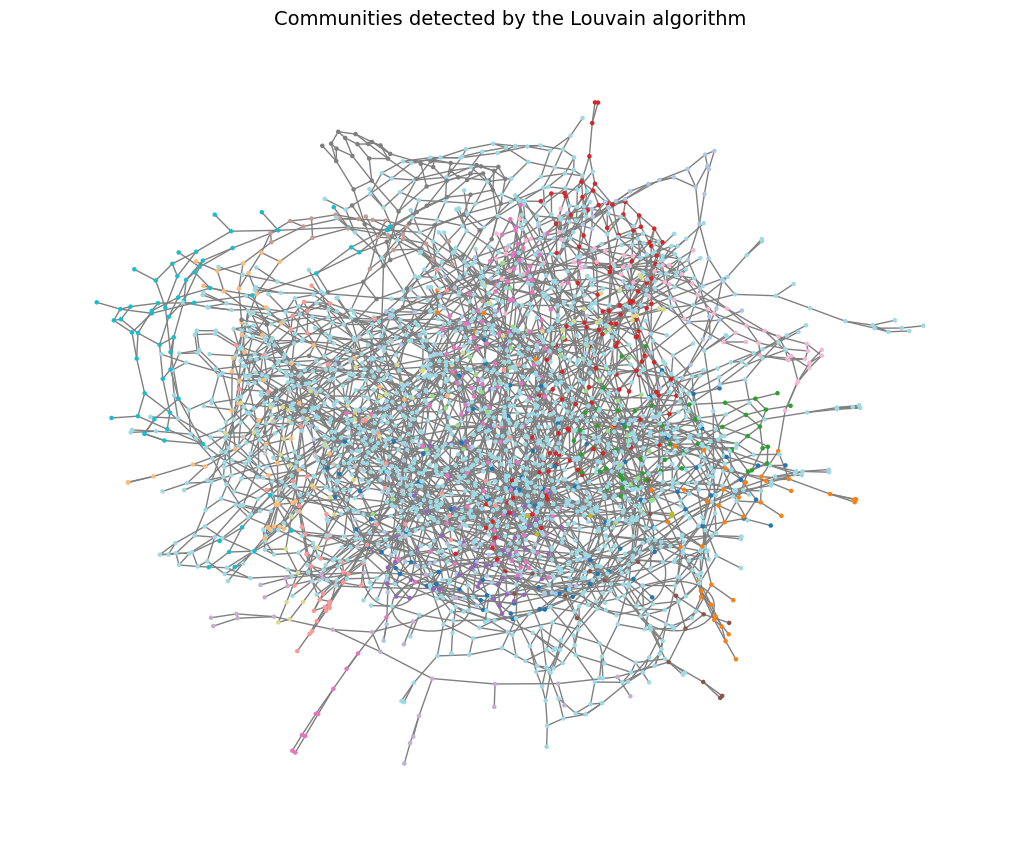

In [10]:
# --- 3. Dibujar el grafo ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Disposición de los nodos (puedes usar otro layout)
nx.draw(
    G, pos, 
    node_color=node_colors, 
    #with_labels=True, 
    node_size=5, 
    #font_size=10, 
    edge_color="gray"
)
plt.title("Communities detected by the Louvain algorithm", fontsize=14)
plt.show()

In [11]:
# --- 3. Optimización ---
max_distance = 30.0
high_risk_nodes = [n for n, data in G.nodes(data=True) if data['prob_rabies'] > 0.8]

len(high_risk_nodes)

583

In [12]:
# Crear modelo
model = LpProblem("Optimization_of_Vaccination_Points", LpMinimize)

# Variables de decisión
x = LpVariable.dicts("Vaccination", G.nodes, cat="Binary")
z = LpVariable.dicts("Not_Covered", high_risk_nodes, cat="Binary")  # Nodos no cubiertos

# --- 4. Optimización basada en comunidades ---
# Agrupar los nodos de alto riesgo por comunidad
communities = {}
for node in high_risk_nodes:
    comunidad = G.nodes[node]['comunidad']
    if comunidad not in communities:
        communities[comunidad] = []
    communities[comunidad].append(node)

# Para cada comunidad, asegurar que esté cubierta
for comunidad, nodes_in_com in communities.items():
    for node in nodes_in_com:
        # Definir la cobertura de cada nodo en esta comunidad
        cobertura = [n for n in G.nodes if nx.has_path(G, n, node) and nx.dijkstra_path_length(G, n, node, weight='length') <= max_distance]
        model += lpSum(x[n] for n in cobertura) + z[node] >= 1  # Cada nodo debe estar cubierto

# Función objetivo: Minimizar puntos de vacunación, penalizar nodos no cubiertos, y optimizar cobertura por comunidad
model += (
    lpSum(x[n] for n in G.nodes)  # Minimizar puntos de vacunación
    - lpSum(
        G.nodes[node]['prob_rabies'] * lpSum(
            x[n] for n in G.nodes if nx.has_path(G, n, node) and nx.dijkstra_path_length(G, n, node, weight='length') <= max_distance
        ) for node in high_risk_nodes
    )  # Maximizar cobertura ponderada
    + lpSum(10 * z[node] for node in high_risk_nodes)  # Penalizar nodos no cubiertos
)

# Resolver modelo
model.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/pantro/Documentos/GITHUB/doutoradoCS/myenv/lib/python3.12/site-packages/pulp/solverdir/cbc/linux/64/cbc /tmp/8b42c98ac63d45b9844c47b0d7a88cd9-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/8b42c98ac63d45b9844c47b0d7a88cd9-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 588 COLUMNS
At line 13033 RHS
At line 13617 BOUNDS
At line 17232 ENDATA
Problem MODEL has 583 rows, 3614 columns and 1602 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is -72.7852 - 0.00 seconds
Cgl0004I processed model has 495 rows, 990 columns (990 integer (850 of which binary)) and 990 elements
Cbc0038I Initial state - 0 integers unsatisfied sum - 0
Cbc0038I Solution found of -72.7852
Cbc0038I Cleaned solution of -72.7852
Cbc0038I Before mini branch and bound, 990 integers at bound fixed and 0 

1

In [15]:
# --- 5. Resultados ---
selected_vaccination_points = [n for n in G.nodes if value(x[n]) == 1]
not_covered_nodes = [node for node in high_risk_nodes if value(z[node]) == 1]

print("Numero de puntos de vacunación seleccionados:", len(selected_vaccination_points))
print("Puntos de vacunación seleccionados:", selected_vaccination_points)
print("Nodos de alto riesgo no cubiertos:", not_covered_nodes)
print("Porcentaje de cobertura:", (len(high_risk_nodes) - len(not_covered_nodes)) / len(high_risk_nodes) * 100, "%")

Numero de puntos de vacunación seleccionados: 634
Puntos de vacunación seleccionados: [531321521, 531321526, 531321541, 531322095, 531322221, 1252911100, 1252912649, 1252926370, 1252927447, 1252946756, 1252947234, 1253001693, 1253003561, 1253003829, 1253008828, 1253013075, 1253039463, 1264282408, 1264282504, 1264283923, 1264284157, 1264286202, 1264287488, 1264288020, 1264288658, 1264290131, 1264291820, 1264292052, 1264292204, 1264292357, 1264293666, 1264294638, 1264296009, 1264297431, 1264298204, 1264298916, 1264300257, 1264300686, 1264300793, 1264300970, 1264304054, 1264305543, 1264305559, 1264309305, 1264314724, 1264314851, 1264315264, 1264316771, 1264318588, 1264318697, 1264319084, 1264319307, 1264319849, 1264321444, 1264321689, 1264324881, 1264325186, 1264327989, 1264328446, 1264330204, 1264330334, 1264330507, 1264330763, 1264330772, 1264334655, 1264336764, 1264337556, 1264337911, 1264339098, 1264339539, 1264339992, 1264340827, 1264342845, 1264346714, 1264346981, 1264347514, 126434

/home/pantro/Documentos/GITHUB/doutoradoCS/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


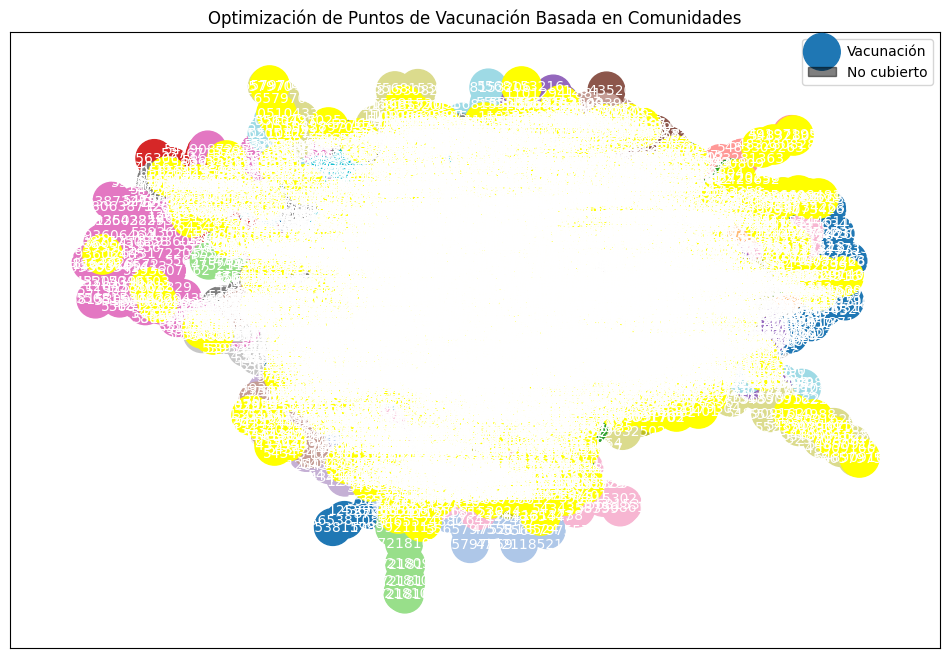

In [16]:
# --- 6. Visualización ---
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 8))

# Colores por comunidad
comunidades = [partition[n] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=700, cmap=plt.cm.tab20, node_color=comunidades)
nx.draw_networkx_edges(G, pos, width=1, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_color="white")

# Resaltamos puntos de vacunación
nx.draw_networkx_nodes(G, pos, nodelist=selected_vaccination_points, node_size=800, node_color="yellow", label="Vacunación")

# Resaltamos nodos no cubiertos
nx.draw_networkx_nodes(G, pos, nodelist=not_covered_nodes, node_size=800, node_color="orange", label="No cubierto")

plt.title("Optimización de Puntos de Vacunación Basada en Comunidades")
plt.legend(["Vacunación", "No cubierto"])
plt.show()